In [2]:
import os
import re
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
os.chdir('/home/ST_Data/scData/RNA')

In [4]:
from scipy.sparse import issparse, csr_matrix

In [5]:
#====Step 1 coarse label annotation==========================
# 1. sample file (cellranger filtered bc matrix) after ambient RNA
sample_dirs = {
'ZD013_S1':"ZD013_S1_0.2ZL_filtered_feature_bc_matrix",
'ZD013_S2':"ZD013_S2_ZL_filtered_feature_bc_matrix",
'ZD014_S1':"ZD014_S1_0.2_ZL_filtered_feature_bc_matrix",
'ZD014_S2':"ZD014_S2_ZL_filtered_feature_bc_matrix",
'ZD015_S1':"ZD015_S1_0.2ZL_filtered_feature_bc_matrix",
'ZD015_S2':"ZD015_S2_ZL_filtered_feature_bc_matrix",
'ZD016C2_S1':"ZD016C2_S1_ZL_filtered_feature_bc_matrix",
'ZD016_S1':"ZD016_S1_ZL_filtered_feature_bc_matrix",
'ZD016_S2':"ZD016_S2_ZL_filtered_feature_bc_matrix",
'ZD020C2-S2':"ZD020C2-S2_filtered_feature_bc_matrix",
'ZD020_S1':"ZD020_S1_ZL_filtered_feature_bc_matrix"
}

In [14]:
hep_bg = [
    "ALB", "HP", "APOE", "TTR", "APOA1", "APOA2", "APOC3",
    "FGA", "FGB", "FGG", "AHSG", "RBP4", "TF"
]

In [9]:
import numpy as np
import scanpy as sc
import anndata as ad
from scipy.sparse import issparse, csr_matrix

adatas = []
for sample, path in sample_dirs.items():
    a = sc.read_10x_mtx(path, var_names="gene_symbols", cache=True)
    a.var_names_make_unique()
    a.obs_names = [f"{sample}_{x}" for x in a.obs_names]
    a.obs["sample"] = sample

    if not issparse(a.X):
        a.X = csr_matrix(a.X)
    else:
        a.X = a.X.tocsr()

    a.layers["counts"] = a.X.copy()
    adatas.append(a)

# 2. QC for each sample
def add_qc_metrics(adata):
    adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")
    adata.var["ribo"] = adata.var_names.str.upper().str.match(r"^RP[SL]")
    adata.var["hb"] = adata.var_names.str.upper().str.match(r"^HB(?!P)")
    adata.var["ig"] = adata.var_names.str.upper().str.match(r"^IG[HKL]")

    sc.pp.calculate_qc_metrics(
        adata,
        qc_vars=["mt", "ribo", "hb", "ig"],
        inplace=True,
        percent_top=None,
        log1p=False,
    )

for a in adatas:
    add_qc_metrics(a)

# 3. basic filteration
filtered = []
for a in adatas:
    a = a[
        (a.obs["n_genes_by_counts"] > 200) &
        (a.obs["total_counts"] > 500) &
        (a.obs["pct_counts_mt"] < 20)
    ].copy()
    filtered.append(a)

# 4. scrublet，save as 'high_risk_doublet' in obs
for a in filtered:
    sc.external.pp.scrublet(a, copy=False)
    a.obs["predicted_doublet_scrublet"] = a.obs["predicted_doublet"].copy()

    ds_thr = np.quantile(a.obs["doublet_score"], 0.98)
    ng_thr = np.quantile(a.obs["n_genes_by_counts"], 0.98)
    ct_thr = np.quantile(a.obs["total_counts"], 0.98)

    a.obs["high_risk_doublet"] = (
        (a.obs["doublet_score"] > ds_thr) &
        (
            (a.obs["n_genes_by_counts"] > ng_thr) |
            (a.obs["total_counts"] > ct_thr)
        )
    )

# 5. Merge
adata = ad.concat(
    filtered,
    join="outer",
    label="sample_merge",
    keys=[a.obs["sample"].iloc[0] for a in filtered],
    fill_value=0
)

# Sparse output
if not issparse(adata.X):
    adata.X = csr_matrix(adata.X)
else:
    adata.X = adata.X.tocsr()

if "counts" in adata.layers:
    if not issparse(adata.layers["counts"]):
        adata.layers["counts"] = csr_matrix(adata.layers["counts"])
    else:
        adata.layers["counts"] = adata.layers["counts"].tocsr()

/home/wr/anaconda3/envs/scvi-pypi/lib/python3.10/site-packages/sklearn/utils/deprecation.py:95: FutureWarning: Function scrublet is deprecated; Import from sc.pp instead
  warnings.warn(msg, category=FutureWarning)
/home/wr/anaconda3/envs/scvi-pypi/lib/python3.10/site-packages/sklearn/utils/deprecation.py:95: FutureWarning: Function scrublet is deprecated; Import from sc.pp instead
  warnings.warn(msg, category=FutureWarning)
/home/wr/anaconda3/envs/scvi-pypi/lib/python3.10/site-packages/sklearn/utils/deprecation.py:95: FutureWarning: Function scrublet is deprecated; Import from sc.pp instead
  warnings.warn(msg, category=FutureWarning)
/home/wr/anaconda3/envs/scvi-pypi/lib/python3.10/site-packages/sklearn/utils/deprecation.py:95: FutureWarning: Function scrublet is deprecated; Import from sc.pp instead
  warnings.warn(msg, category=FutureWarning)
/home/wr/anaconda3/envs/scvi-pypi/lib/python3.10/site-packages/sklearn/utils/deprecation.py:95: FutureWarning: Function scrublet is deprecat

ImportError: Please install skmisc package via `pip install --user scikit-misc

In [15]:
# 8. HVGs
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=3000,
    batch_key="sample",
    #layer="counts",
    flavor="seurat"
)

# exclude background genes

exclude = (
   # adata.var_names.str.upper().str.match(r"^IG[HKL]") |
   adata.var_names.str.upper().str.match(r"^MT-") |
   adata.var_names.str.upper().str.match(r"^RP[SL]") |
   adata.var_names.str.upper().str.match(r"^HB(?!P)")|
   adata.var_names.str.upper().isin(hep_bg)
)
adata.var["highly_variable"] = adata.var["highly_variable"] & (~exclude)

# 9. PCA / neighbors / UMAP / clustering
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, use_highly_variable=True)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5,flavor="igraph")

/home/wr/anaconda3/envs/scvi-pypi/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/home/wr/anaconda3/envs/scvi-pypi/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(
/home/wr/anaconda3/envs/scvi-pypi/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_684401/745457804.py:26: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defau

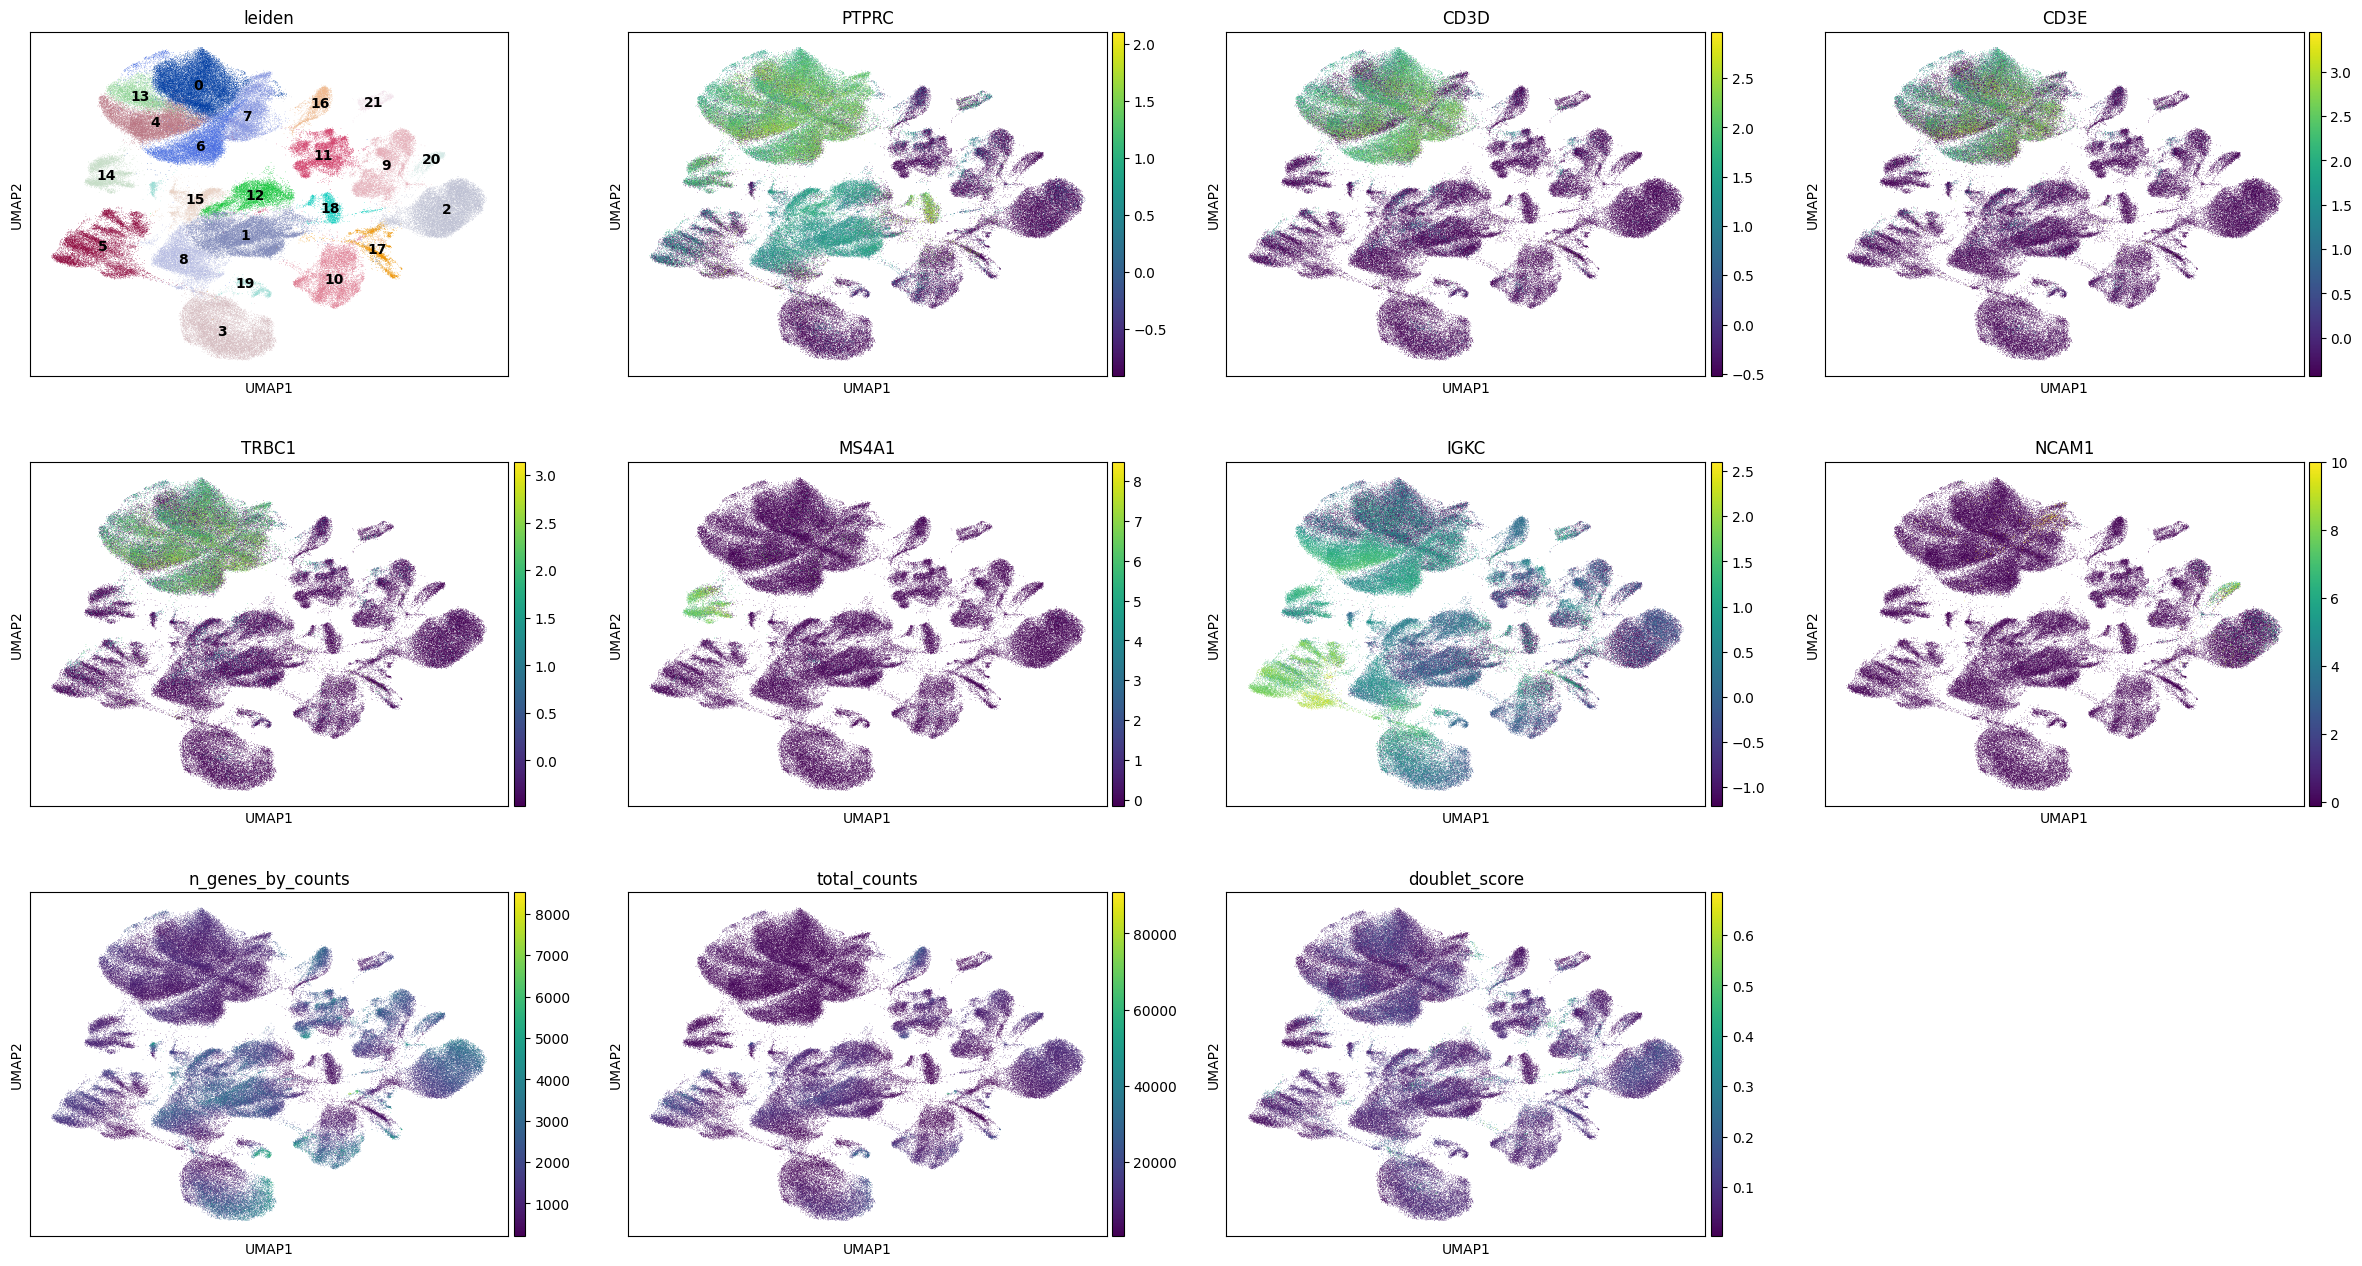

In [16]:
#pip install scrublet
# 10. classic markers of main cell types
sc.pl.umap(adata, color=["leiden",'PTPRC', "CD3D", "CD3E", "TRBC1", "MS4A1", "IGKC", "NCAM1", "n_genes_by_counts", "total_counts", "doublet_score"],legend_loc='on data',save='_coarse_label_rm_dp.pdf')

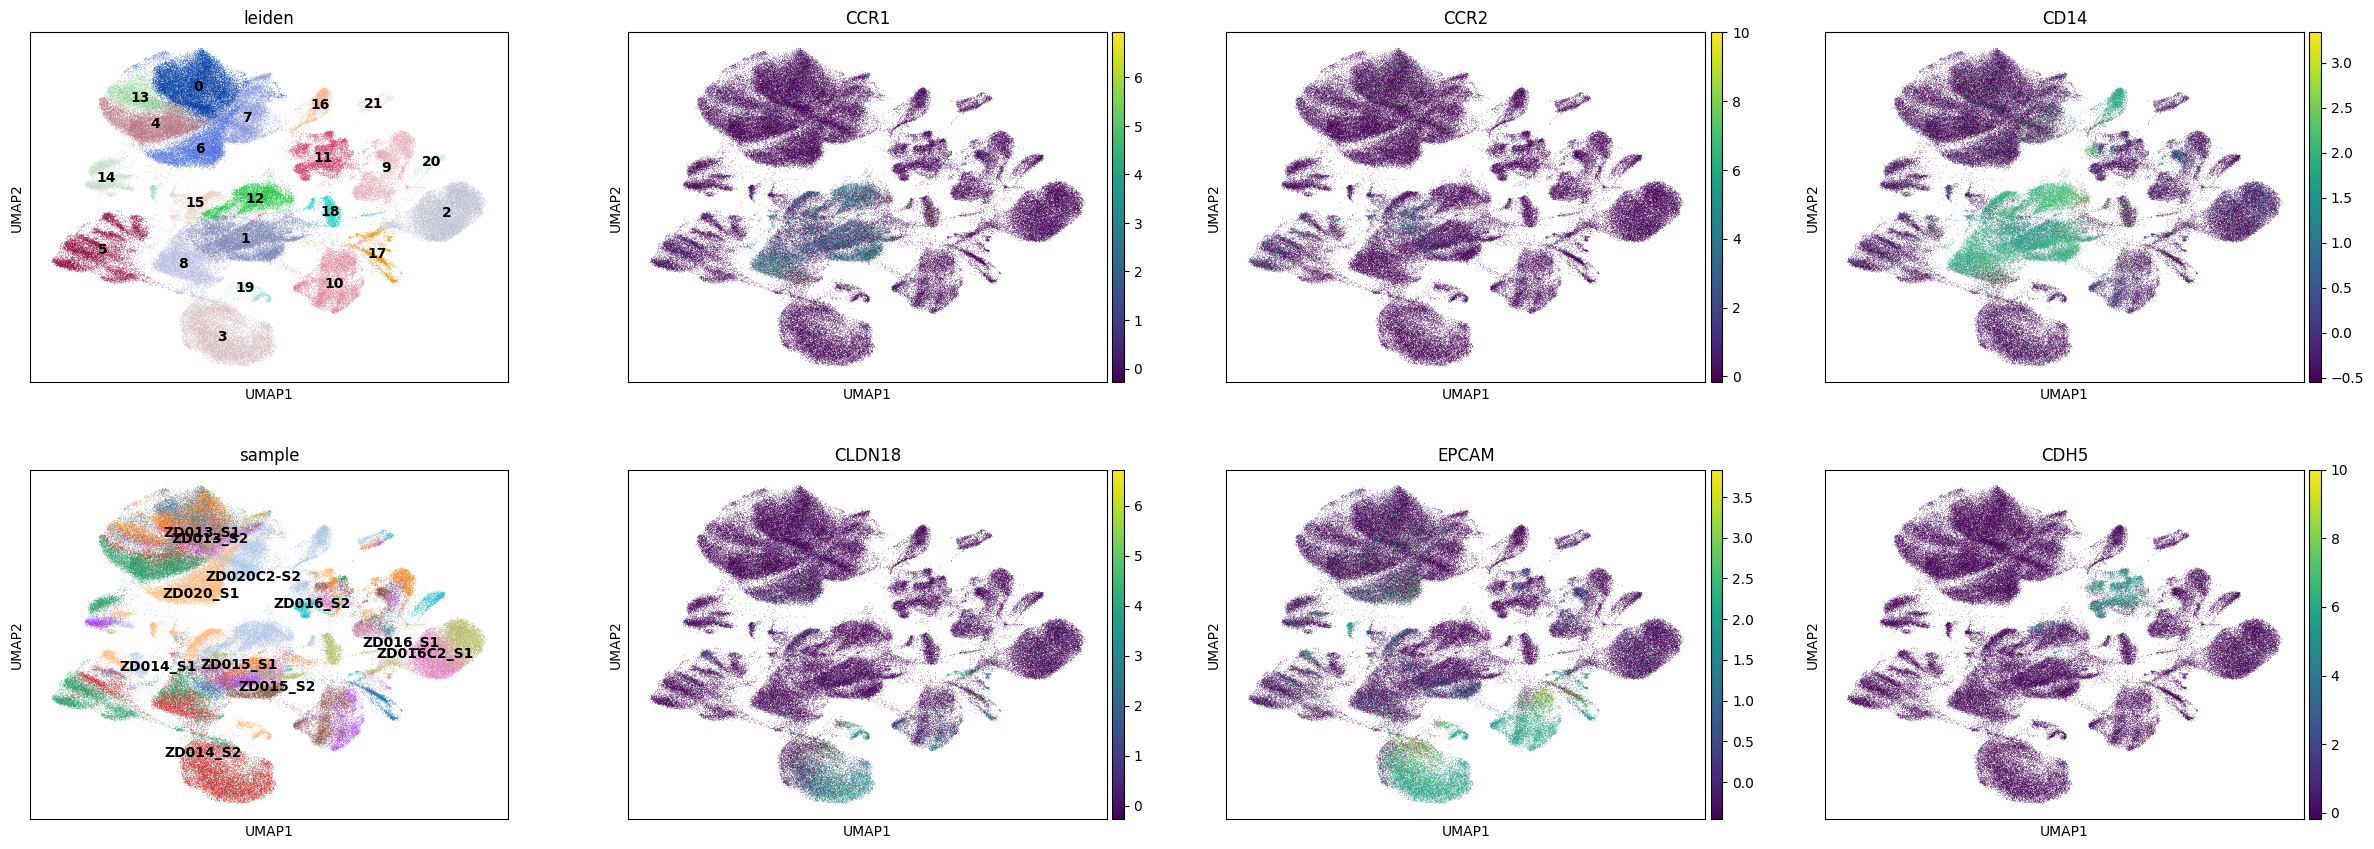

In [17]:
sc.pl.umap(adata, color=["leiden",'CCR1','CCR2','CD14','sample','CLDN18','EPCAM','CDH5'],legend_loc='on data',save= '_coarse_label_ccr1.pdf')

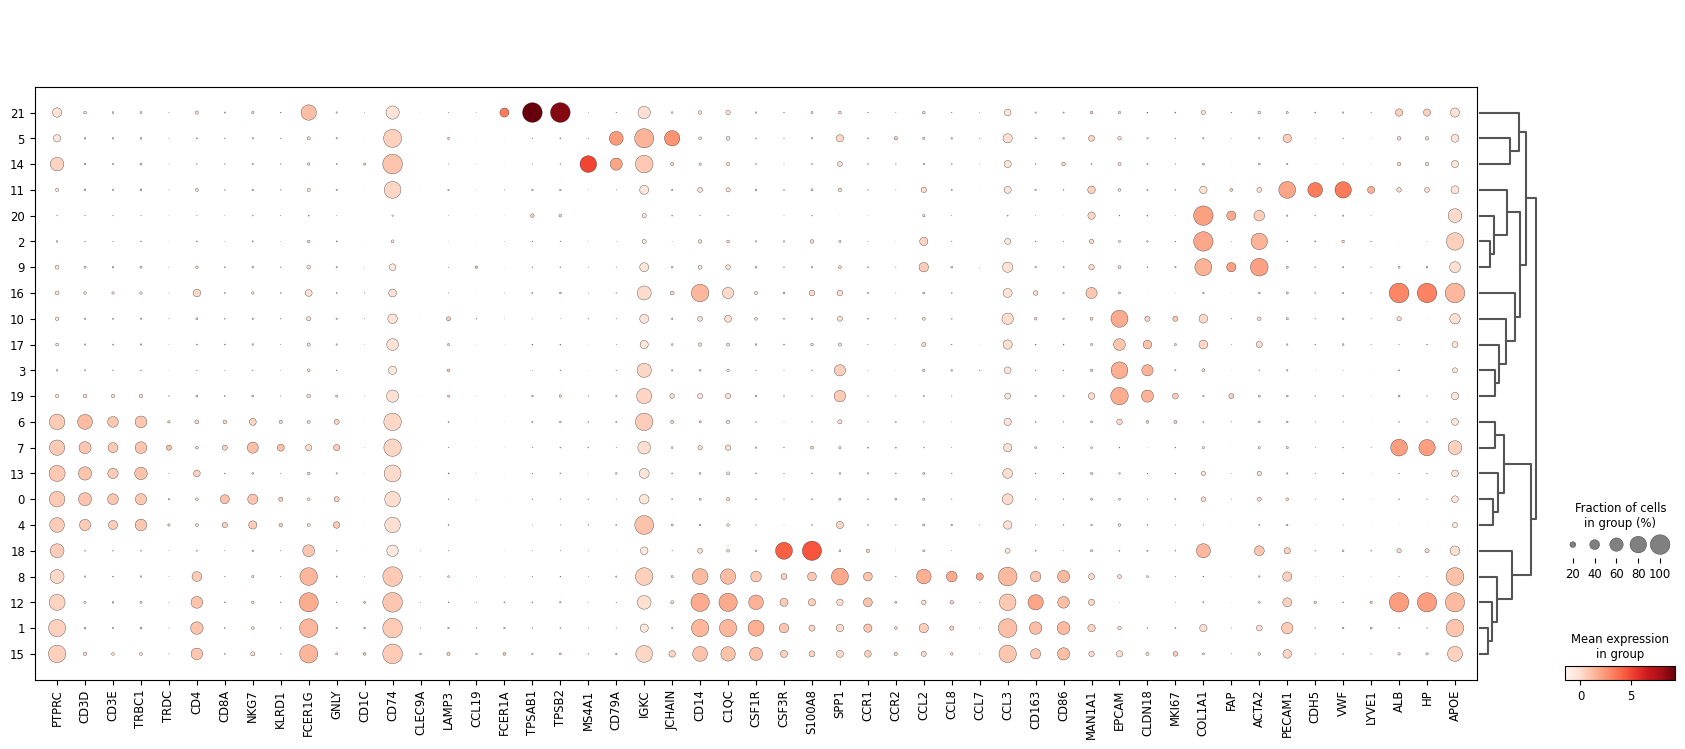

In [27]:
sc.pl.dotplot(adata,['PTPRC', "CD3D", "CD3E", "TRBC1","TRDC",
                     'CD4','CD8A','NKG7','KLRD1','FCER1G','GNLY',
                     'CD1C','CD74','CLEC9A','LAMP3','CCL19','FCER1A',
                     'TPSAB1','TPSB2',
                     "MS4A1", "CD79A", "IGKC", "JCHAIN",
                     'CD14','C1QC','CSF1R','CSF3R','S100A8','SPP1','CCR1','CCR2',
                     'CCL2','CCL8','CCL7','CCL3',
                     'CD163','CD86','MAN1A1',
                     'EPCAM','CLDN18','MKI67',
                     'COL1A1','FAP','ACTA2','PECAM1','CDH5','VWF','LYVE1',
                     'ALB','HP','APOE'],groupby='leiden',dendrogram=True,save='_coarse_label_pdf')

In [29]:
cluster2label = {  
'21':'Mast',
'14':'B',
'5':'Plasma',
'11':'EC',
'20':'aCAF',
'2':'qCAF',
'9':'aCAF',
'16':'Hepa-like',
'3':'Tumor',
'19':'Tumor',
'6':'T/NK',
'7':'T/NK',
'13':'T/NK',
'0':'T/NK',
'4':'T/NK',
'18':'Neu',
'8':'SPP1_Macro',
'12':'Macro',
'1':'Macro',
'15':'Macro'
}

In [30]:
adata.obs["coarse_label"] = adata.obs["leiden"].map(cluster2label).fillna("Unknown")
adata.obs["coarse_label"] = adata.obs["coarse_label"].astype("category")

In [31]:
adata.obs.to_csv('obs_coarse_label.csv')

In [32]:
#save merged coarse data first 
import os
import gzip
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.io import mmwrite

def write_adata_counts_to_10x_mtx(
    adata,
    outdir,
    layer="counts",
    barcode_col=None,
    gene_id_col=None,
    gene_symbol_col=None,
    feature_type="Gene Expression",
    compress=True,
):
    """
    将 AnnData 的 counts layer 导出成 10x mtx 目录，可被 scanpy.read_10x_mtx 读取。

    输出文件：
      - matrix.mtx(.gz)
      - barcodes.tsv(.gz)
      - features.tsv(.gz)

    参数
    ----
    adata : AnnData
    outdir : str
        输出目录
    layer : str
        原始计数所在 layer，默认 'counts'
    barcode_col : str or None
        若 obs 中某列存 barcode，则优先使用；否则使用 adata.obs_names
    gene_id_col : str or None
        features 第一列。优先使用 adata.var[gene_id_col]；否则自动尝试常见列名；
        再不行就退化为 adata.var_names
    gene_symbol_col : str or None
        features 第二列。优先使用 adata.var[gene_symbol_col]；否则使用 adata.var_names
    feature_type : str
        features 第三列，默认 'Gene Expression'
    compress : bool
        是否写成 .gz
    """
    os.makedirs(outdir, exist_ok=True)

    # -------------------------
    # 1)  counts
    # -------------------------
    if layer not in adata.layers:
        raise ValueError(f"adata.layers['{layer}'] 不存在。")

    X = adata.layers[layer]

    # 10x matrix.mtx 期望 genes x cells
    # AnnData 是 cells x genes，所以要转置
    if sp.issparse(X):
        X = X.tocoo().astype(np.float32)
    else:
        X = sp.coo_matrix(np.asarray(X, dtype=np.float32))

    X = X.transpose().tocoo()  # genes x cells

    # -------------------------
    # 2) barcodes
    # -------------------------
    if barcode_col is not None:
        if barcode_col not in adata.obs.columns:
            raise ValueError(f"barcode_col='{barcode_col}' 不在 adata.obs.columns 中。")
        barcodes = adata.obs[barcode_col].astype(str).values
    else:
        barcodes = adata.obs_names.astype(str).values

    # -------------------------
    # 3) features
    # -------------------------
    # gene_symbol
    if gene_symbol_col is not None:
        if gene_symbol_col not in adata.var.columns:
            raise ValueError(f"gene_symbol_col='{gene_symbol_col}' 不在 adata.var.columns 中。")
        gene_symbols = adata.var[gene_symbol_col].astype(str).values
    else:
        gene_symbols = adata.var_names.astype(str).values

    # gene_id
    if gene_id_col is not None:
        if gene_id_col not in adata.var.columns:
            raise ValueError(f"gene_id_col='{gene_id_col}' 不在 adata.var.columns 中。")
        gene_ids = adata.var[gene_id_col].astype(str).values
    else:
        # 自动尝试常见列名
        candidate_cols = ["gene_ids", "gene_id", "ensembl_id", "ensembl", "feature_id", "id"]
        found = None
        for c in candidate_cols:
            if c in adata.var.columns:
                found = c
                break
        if found is not None:
            gene_ids = adata.var[found].astype(str).values
        else:
            gene_ids = adata.var_names.astype(str).values

    feature_types = np.array([feature_type] * adata.n_vars, dtype=object)

    features_df = pd.DataFrame({
        0: gene_ids,
        1: gene_symbols,
        2: feature_types,
    })

    # -------------------------
    # 4) 10X_MTX OUT
    # -------------------------
    matrix_path = os.path.join(outdir, "matrix.mtx")
    barcodes_path = os.path.join(outdir, "barcodes.tsv")
    features_path = os.path.join(outdir, "features.tsv")

    mmwrite(matrix_path, X)

    pd.Series(barcodes).to_csv(
        barcodes_path,
        sep="\t",
        index=False,
        header=False
    )

    features_df.to_csv(
        features_path,
        sep="\t",
        index=False,
        header=False
    )

    # -------------------------
    # 5) gzip
    # -------------------------
    if compress:
        for path in [matrix_path, barcodes_path, features_path]:
            gz_path = path + ".gz"
            with open(path, "rb") as f_in, gzip.open(gz_path, "wb") as f_out:
                f_out.writelines(f_in)
            os.remove(path)

    print(f"Done. Files written to: {outdir}")
    print("Contains:")
    if compress:
        print("  matrix.mtx.gz")
        print("  barcodes.tsv.gz")
        print("  features.tsv.gz")
    else:
        print("  matrix.mtx")
        print("  barcodes.tsv")
        print("  features.tsv")

In [33]:
#-----save coarse clean raw matrix-------------------
write_adata_counts_to_10x_mtx(
    adata,
    outdir="ref_merge_coarse_10x",
    layer="counts"
)

Done. Files written to: ref_merge_coarse_10x
Contains:
  matrix.mtx.gz
  barcodes.tsv.gz
  features.tsv.gz


In [34]:
import os
import gc
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import scvi

# -----------------------------
# 0) Basic, space-saving
# -----------------------------
scvi.settings.seed = 0
# 有GPU就自动用GPU；没有也可跑
ACCELERATOR = "auto"
DEVICES = "auto"

# 避免 float64
if sp.issparse(adata.X):
    adata.X = adata.X.astype(np.float32)
else:
    adata.X = np.asarray(adata.X, dtype=np.float32)

if "counts" not in adata.layers:
    raise ValueError("adata.layers['counts'] 不存在，请先把原始counts放进去。")

if sp.issparse(adata.layers["counts"]):
    adata.layers["counts"] = adata.layers["counts"].astype(np.float32).tocsr()
else:
    adata.layers["counts"] = np.asarray(adata.layers["counts"], dtype=np.float32)

adata.var_names_make_unique()


gc.collect()

Seed set to 0


60

In [35]:
# -----------------------------
# 1) "coarse label" for SCANVI training
#    mixed cells labelled as 'Unknown'
# -----------------------------
LABEL_KEY = "coarse_label"
BATCH_KEY = "sample"
COUNTS_LAYER = "counts"
UNLABELED = "Unknown"

if LABEL_KEY not in adata.obs:
    raise ValueError(f"adata.obs['{LABEL_KEY}'] 不存在。")

adata.obs[LABEL_KEY] = adata.obs[LABEL_KEY].astype("category")

# 如果有缺失标签，补成 Unknown
mask_na = adata.obs[LABEL_KEY].isna()
if mask_na.any():
    adata.obs.loc[mask_na, LABEL_KEY] = UNLABELED

# categories 里确保包含 Unknown
adata.obs[LABEL_KEY] = adata.obs[LABEL_KEY].astype(str)
adata.obs[LABEL_KEY] = adata.obs[LABEL_KEY].fillna(UNLABELED)
adata.obs[LABEL_KEY] = pd.Categorical(adata.obs[LABEL_KEY])

In [36]:
# -----------------------------
# 2) 只为 scvi/scANVI 准备一个“轻量 reference”
#    不保留 scale/PCA/neighbors/umap 等大对象
# -----------------------------
keep_obs = [BATCH_KEY, LABEL_KEY]
extra_obs = [c for c in keep_obs if c in adata.obs.columns]

adata_ref = sc.AnnData(
    X=adata.layers[COUNTS_LAYER],      # 直接用 counts 作为 X，避免额外拷贝
    obs=adata.obs[extra_obs].copy(),
    var=adata.var.copy()
)
adata_ref.layers[COUNTS_LAYER] = adata.layers[COUNTS_LAYER]  # 显式保留 counts layer
adata_ref.var_names_make_unique()

# 删除无关的大 obsm/varm/uns/layers，尽量省内存
adata_ref.obsm.clear()
adata_ref.varm.clear()
adata_ref.obsp.clear()
adata_ref.varp.clear()
adata_ref.uns.clear()

# 确保都是 CSR + float32
if sp.issparse(adata_ref.X):
    adata_ref.X = adata_ref.X.astype(np.float32).tocsr()
else:
    adata_ref.X = np.asarray(adata_ref.X, dtype=np.float32)

if sp.issparse(adata_ref.layers[COUNTS_LAYER]):
    adata_ref.layers[COUNTS_LAYER] = adata_ref.layers[COUNTS_LAYER].astype(np.float32).tocsr()
else:
    adata_ref.layers[COUNTS_LAYER] = np.asarray(adata_ref.layers[COUNTS_LAYER], dtype=np.float32)


In [38]:
# -----------------------------
# 1) "coarse label" for SCANVI training
#    mixed cells labelled as 'Unknown'
# -----------------------------
LABEL_KEY = "coarse_label"
BATCH_KEY = "sample"
COUNTS_LAYER = "counts"
UNLABELED = "Unknown"

if LABEL_KEY not in adata.obs:
    raise ValueError(f"adata.obs['{LABEL_KEY}'] 不存在。")

adata.obs[LABEL_KEY] = adata.obs[LABEL_KEY].astype("category")

# 如果有缺失标签，补成 Unknown
mask_na = adata.obs[LABEL_KEY].isna()
if mask_na.any():
    adata.obs.loc[mask_na, LABEL_KEY] = UNLABELED

# categories 里确保包含 Unknown
adata.obs[LABEL_KEY] = adata.obs[LABEL_KEY].astype(str)
adata.obs[LABEL_KEY] = adata.obs[LABEL_KEY].fillna(UNLABELED)
adata.obs[LABEL_KEY] = pd.Categorical(adata.obs[LABEL_KEY])


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 3080') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/wr/anaconda3/envs/scvi-pypi/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in 

Epoch 200/200: 100%|██████████| 200/200 [1:52:18<00:00, 33.71s/it, v_num=1, train_loss_step=4.31e+3, train_loss_epoch=4.37e+3]

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 200/200: 100%|██████████| 200/200 [1:52:18<00:00, 33.69s/it, v_num=1, train_loss_step=4.31e+3, train_loss_epoch=4.37e+3]
INFO     Training for 50 epochs.                                                                                   


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/wr/anaconda3/envs/scvi-pypi/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/home/wr/anaconda3/envs/scvi-pypi/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 46/50:  92%|█████████▏| 46/50 [44:48<03:53, 58.45s/it, v_num=1, train_loss_step=4.5e+3, train_loss_epoch=4.35e+3] 
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 4418.492. Signaling Trainer to stop.


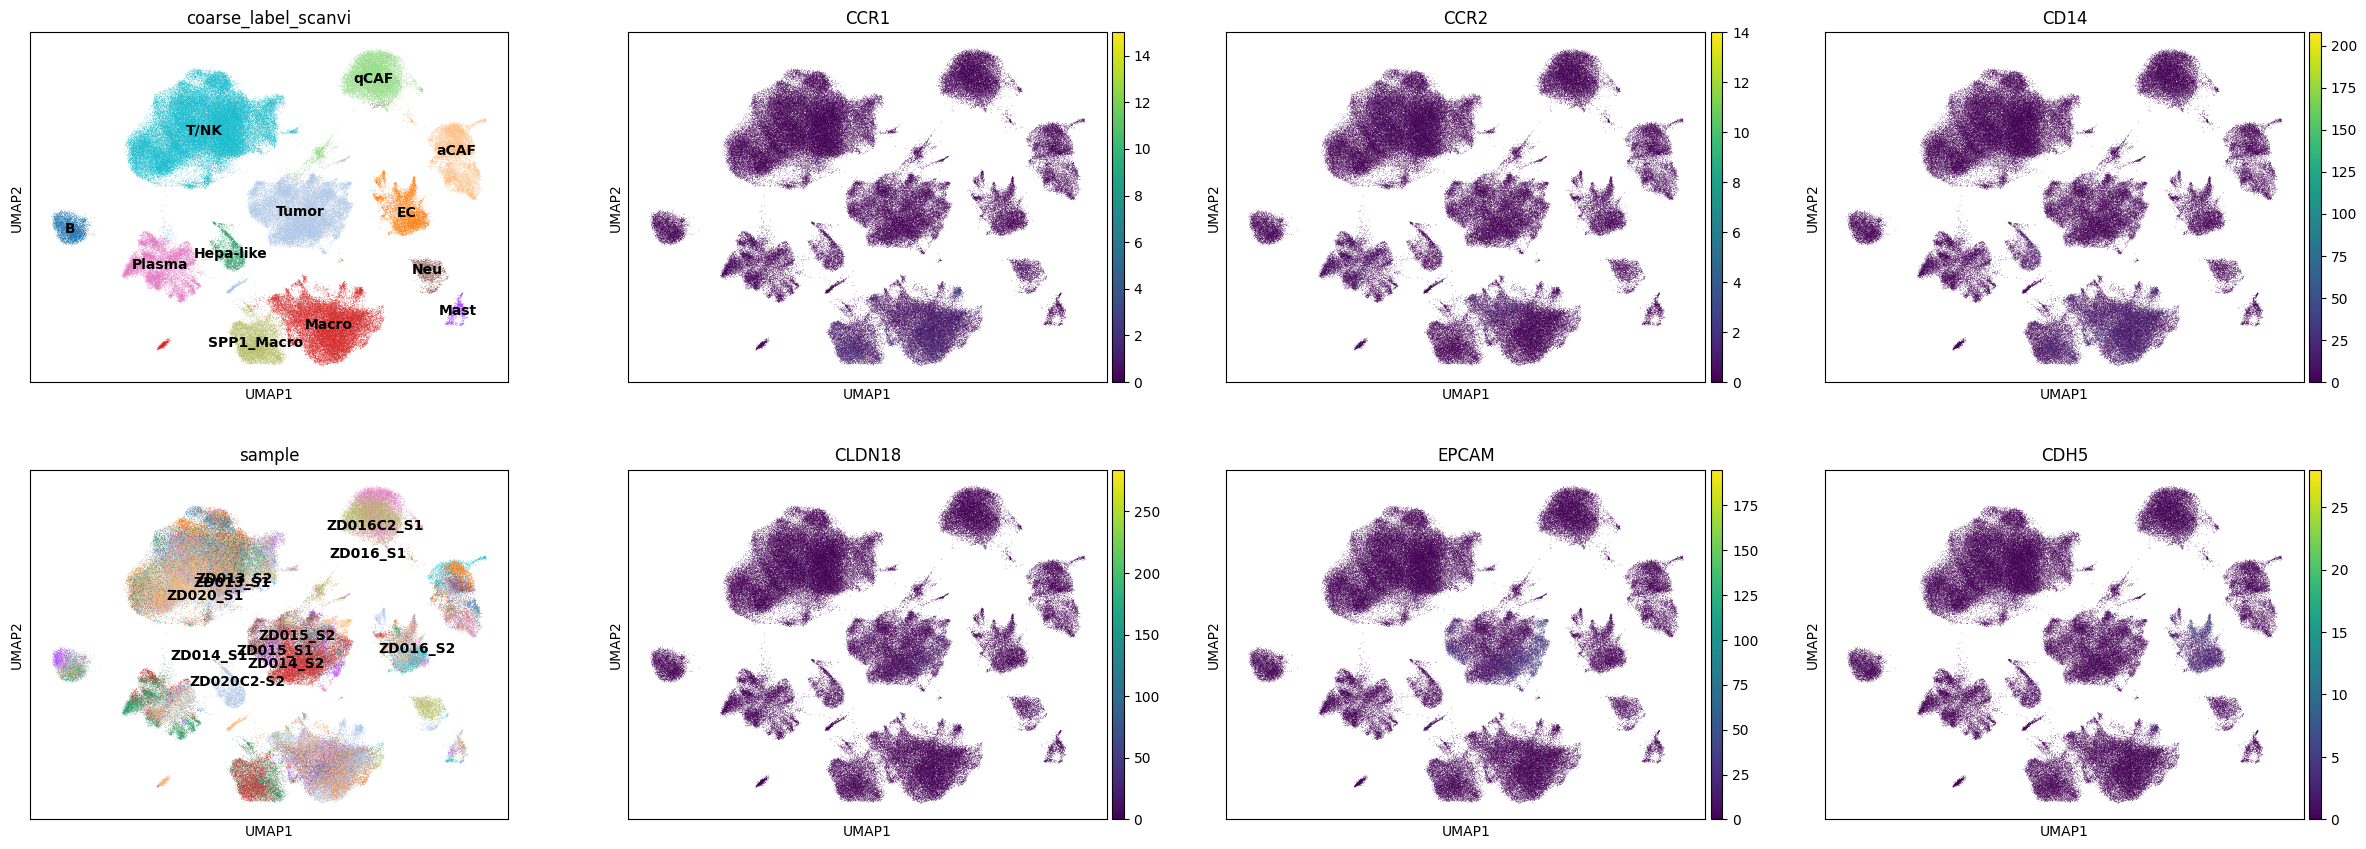

In [39]:
# -----------------------------
# 5) Optional, scanvi latent shows scANVI adjusted labels
# -----------------------------
sc.pp.neighbors(adata_ref, use_rep="X_scANVI", n_neighbors=15)
sc.tl.umap(adata_ref)
sc.pl.umap(adata_ref, color=["coarse_label_scanvi",'CCR1','CCR2','CD14','sample','CLDN18','EPCAM','CDH5'],legend_loc='on data',save= '_coarse_label_scanvi_ccr1.pdf')

In [8]:
sc.pl.dotplot(adata_cond,['PTPRC', "CD3D", "CD3E", "TRBC1",
                     'NKG7','KLRD1','FCER1G','GNLY',
                     'CD1C','CLEC9A','LAMP3','CCL19','FCER1A',
                     'TPSAB1','TPSB2',
                     "MS4A1", "CD79A", "JCHAIN",'IGKC',
                     'CD14','C1QC','CSF1R','CSF3R','S100A8','SPP1',
                     'CCR1','CCR2','CCR5',
                     'CCL2','CCL8','CCL7','CCL3',
                     'CD163','CD86','MAN1A1',
                     'EPCAM','CLDN18','MKI67',
                     'COL1A1','FAP','ACTA2','PECAM1','CDH5','VWF','LYVE1',
                     'ALB','HP','APOE'],groupby='coarse_label_scanvi',dendrogram=True)
              #save='_coarse_label_scanvi_pdf')

/home/wr/anaconda3/envs/scvi-pypi/lib/python3.10/site-packages/scanpy/tools/_dendrogram.py:138: UserWarning: You’re trying to run this on 60676 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  _choose_representation(adata, use_rep=use_rep, n_pcs=n_pcs)


ArpackError: ARPACK error -9: Starting vector is zero.

In [7]:
adata_cond.X=adata_cond.layers['counts']

In [48]:
# -----------------------------
# 6) CondSCVI models，RNA reference
#   CondSCVI + labels_key + counts layer(float32)
# -----------------------------
# minize reference and save the space

counts = adata_ref.layers[COUNTS_LAYER]
if sp.issparse(counts):
    counts = counts.astype(np.float32).tocsr()
else:
    counts = sp.csr_matrix(np.asarray(counts, dtype=np.float32))

# 最少信息
#FINAL_LABEL_KEYS=[FINAL_LABEL_KEY,'sample','coarse','leiden']
obs_min = adata_ref.obs.copy()
#var_min = pd.DataFrame(index=adata_ref.var_names.copy())

adata_cond = sc.AnnData(
    X=sp.csr_matrix(counts.shape, dtype=np.float32),
    obs=obs_min.copy(),
    var=adata_ref.var.copy(),
)

adata_cond.layers[COUNTS_LAYER] = counts
adata_cond.var_names_make_unique()

adata_cond.obsm.clear()
adata_cond.varm.clear()
adata_cond.obsp.clear()
adata_cond.varp.clear()
adata_cond.uns.clear()

'''
if sp.issparse(adata_cond.X):
    adata_cond.X = adata_cond.X.astype(np.float32).tocsr()
else:
    adata_cond.X = np.asarray(adata_cond.X, dtype=np.float32)

if sp.issparse(adata_cond.layers[COUNTS_LAYER]):
    adata_cond.layers[COUNTS_LAYER] = adata_cond.layers[COUNTS_LAYER].astype(np.float32).tocsr()
else:
    adata_cond.layers[COUNTS_LAYER] = np.asarray(adata_cond.layers[COUNTS_LAYER], dtype=np.float32)
'''

'\nif sp.issparse(adata_cond.X):\n    adata_cond.X = adata_cond.X.astype(np.float32).tocsr()\nelse:\n    adata_cond.X = np.asarray(adata_cond.X, dtype=np.float32)\n\nif sp.issparse(adata_cond.layers[COUNTS_LAYER]):\n    adata_cond.layers[COUNTS_LAYER] = adata_cond.layers[COUNTS_LAYER].astype(np.float32).tocsr()\nelse:\n    adata_cond.layers[COUNTS_LAYER] = np.asarray(adata_cond.layers[COUNTS_LAYER], dtype=np.float32)\n'

In [54]:
outdir = "destvi_reference"
os.makedirs(outdir, exist_ok=True)

# save RNA reference h5ad
adata_cond.write_h5ad(
    os.path.join(outdir, "scrna_refer_for_destvi.h5ad"),
    compression="gzip"
)


In [55]:
adata_ref.obs.to_csv('obs_scanvi.csv')

In [6]:
adata_cond = sc.read_h5ad('/home/ST_Data/scData/RNA/destvi_reference/scrna_reference_for_destvi.h5ad')

In [7]:
import os
import gc
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import scvi

In [4]:
adata_cond.obs

,sample,coarse_label,_scvi_batch,_scvi_labels,coarse_label_scanvi,coarse_label_scanvi_2,leiden
ZD013_S1_AAACATCGAAACATCGAGTACAAG,ZD013_S1,T/NK,0,4,T/NK,T/NK,4
ZD013_S1_AAACATCGAAACATCGGCTCGGTA,ZD013_S1,T/NK,0,1,T/NK,T/NK,1
ZD013_S1_AAACATCGAACCGAGAAACGTGAT,ZD013_S1,aCAF,0,15,aCAF,aCAF,15
ZD013_S1_AAACATCGAACCGAGAACACAGAA,ZD013_S1,Macro,0,0,Macro,Macro,0
ZD013_S1_AAACATCGAACGCTTACGACTGGA,ZD013_S1,SPP1_Macro,0,8,SPP1_Macro,SPP1_Macro,8
...,...,...,...,...,...,...,...
ZD020_S1_TTCACGCATGAAGAGAAGTACAAG,ZD020_S1,EC,0,9,EC,EC,9
ZD020_S1_TTCACGCATGAAGAGATGAAGAGA,ZD020_S1,Mast,0,20,Mast,Mast,20
ZD020_S1_TTCACGCATGGAACAAACAGCAGA,ZD020_S1,Plasma,0,6,Plasma,Plasma,6
ZD020_S1_TTCACGCATGGCTTCACATACCAA,ZD020_S1,T/NK,0,2,T/NK,T/NK,2


In [15]:
obs = pd.read_csv('/home/ST_Data/scData/RNA/destvi_reference/obs.scanvi_leiden.csv',index_col=0)

In [19]:
adata_cond.obs=obs

In [26]:
adata_cond.write("/home/ST_Data/scData/RNA/destvi_reference/scrna_reference_for_destvi.h5ad")

In [8]:
#LABEL_KEY = "coarse_label"
LABEL_KEY='leiden'
BATCH_KEY = "sample"
COUNTS_LAYER = "counts"
UNLABELED = "Unknown"
scvi.settings.seed = 0
# 有GPU就自动用GPU；没有也可跑
ACCELERATOR = "auto"
DEVICES = "auto"
FINAL_LABEL_KEY='coarse_label_scanvi'
#FINAL_LABEL_KEY='leiden_label_scanvi'

Seed set to 0


In [21]:
scvi.model.CondSCVI.setup_anndata(
    adata_cond,
    layer=COUNTS_LAYER,
    labels_key=LABEL_KEY,
)

condscvi_model = scvi.model.CondSCVI(
    adata_cond,
    weight_obs=False,   # official recommended
)

condscvi_model.train(
    max_epochs=200,
    accelerator=ACCELERATOR,
    devices=DEVICES,
    batch_size=2048,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 3080') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/wr/anaconda3/envs/scvi-pypi/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in 

Epoch 200/200: 100%|██████████| 200/200 [1:55:44<00:00, 35.34s/it, v_num=1, train_loss_step=4.7e+3, train_loss_epoch=4.76e+3] 

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 200/200: 100%|██████████| 200/200 [1:55:44<00:00, 34.72s/it, v_num=1, train_loss_step=4.7e+3, train_loss_epoch=4.76e+3]


In [23]:
outdir = "/home/ST_Data/scData/RNA/destvi_reference"

In [24]:
# -----------------------------
# 7) Optional, save destVI scVI models, recommended
# -----------------------------

# save CondSCVI model, recommended
condscvi_model.save(
    #os.path.join(outdir, "condscvi_model"),
    os.path.join(outdir, "condscvi_model_leiden"),
    overwrite=True,
    save_anndata=True
)

'''
# optional save SCANVI model and results,recommended
scanvi_model.save(
    os.path.join(outdir, "scanvi_model"),
    overwrite=True,
    save_anndata=False
)

adata_ref.write_h5ad(
    os.path.join(outdir, "scrna_scanvi_annotated.h5ad"),
    compression="gzip"
)
'''
print("Done. Saved:")
#print(os.path.join(outdir, "scrna_reference_for_destvi.h5ad"))
print(os.path.join(outdir, "condscvi_model"))
print(os.path.join(outdir, "condscvi_model_leiden"))
#print(os.path.join(outdir, "scanvi_model"))
#print(os.path.join(outdir, "scrna_scanvi_annotated.h5ad"))

Done. Saved:
/home/ST_Data/scData/RNA/destvi_reference/condscvi_model
/home/ST_Data/scData/RNA/destvi_reference/condscvi_model_leiden


In [19]:
#=================Step2 remove doublet and scANVI Label ajustment========================
import scvi

# 1) 读回你之前保存的 obs 信息
obs_df = pd.read_csv("obs_coarse_label.csv", index_col=0)